Porcentaje de valores nulos por columna

Cantidad de nulos por columna
Mestros_cuadrados    2
Habitaciones         1
Precio               2
dtype: int64
Matriz de nulos
Tamaño original: 10 filas
Tamaño despues de eliminacion: 5 filas

Valor calculado de la mediana: 177.5
   Mestros_cuadrados  Habitaciones  Precio
0               85.0           2.0   150.0
1              120.0           3.0   210.0
2                NaN           2.0   140.0
3              250.0           4.0   177.5
4               65.0           1.0    90.0
5              110.0           NaN   195.0
6               95.0           2.0   177.5
7              300.0           5.0   520.0
8                NaN           2.0   160.0
9              150.0           3.0   260.0
Dataframe KNN
   Mestros_cuadrados  Habitaciones  Precio
0               85.0           2.0   150.0
1              120.0           3.0   210.0
2              172.5           2.0   140.0
3              250.0           4.0   150.0
4               65.0      

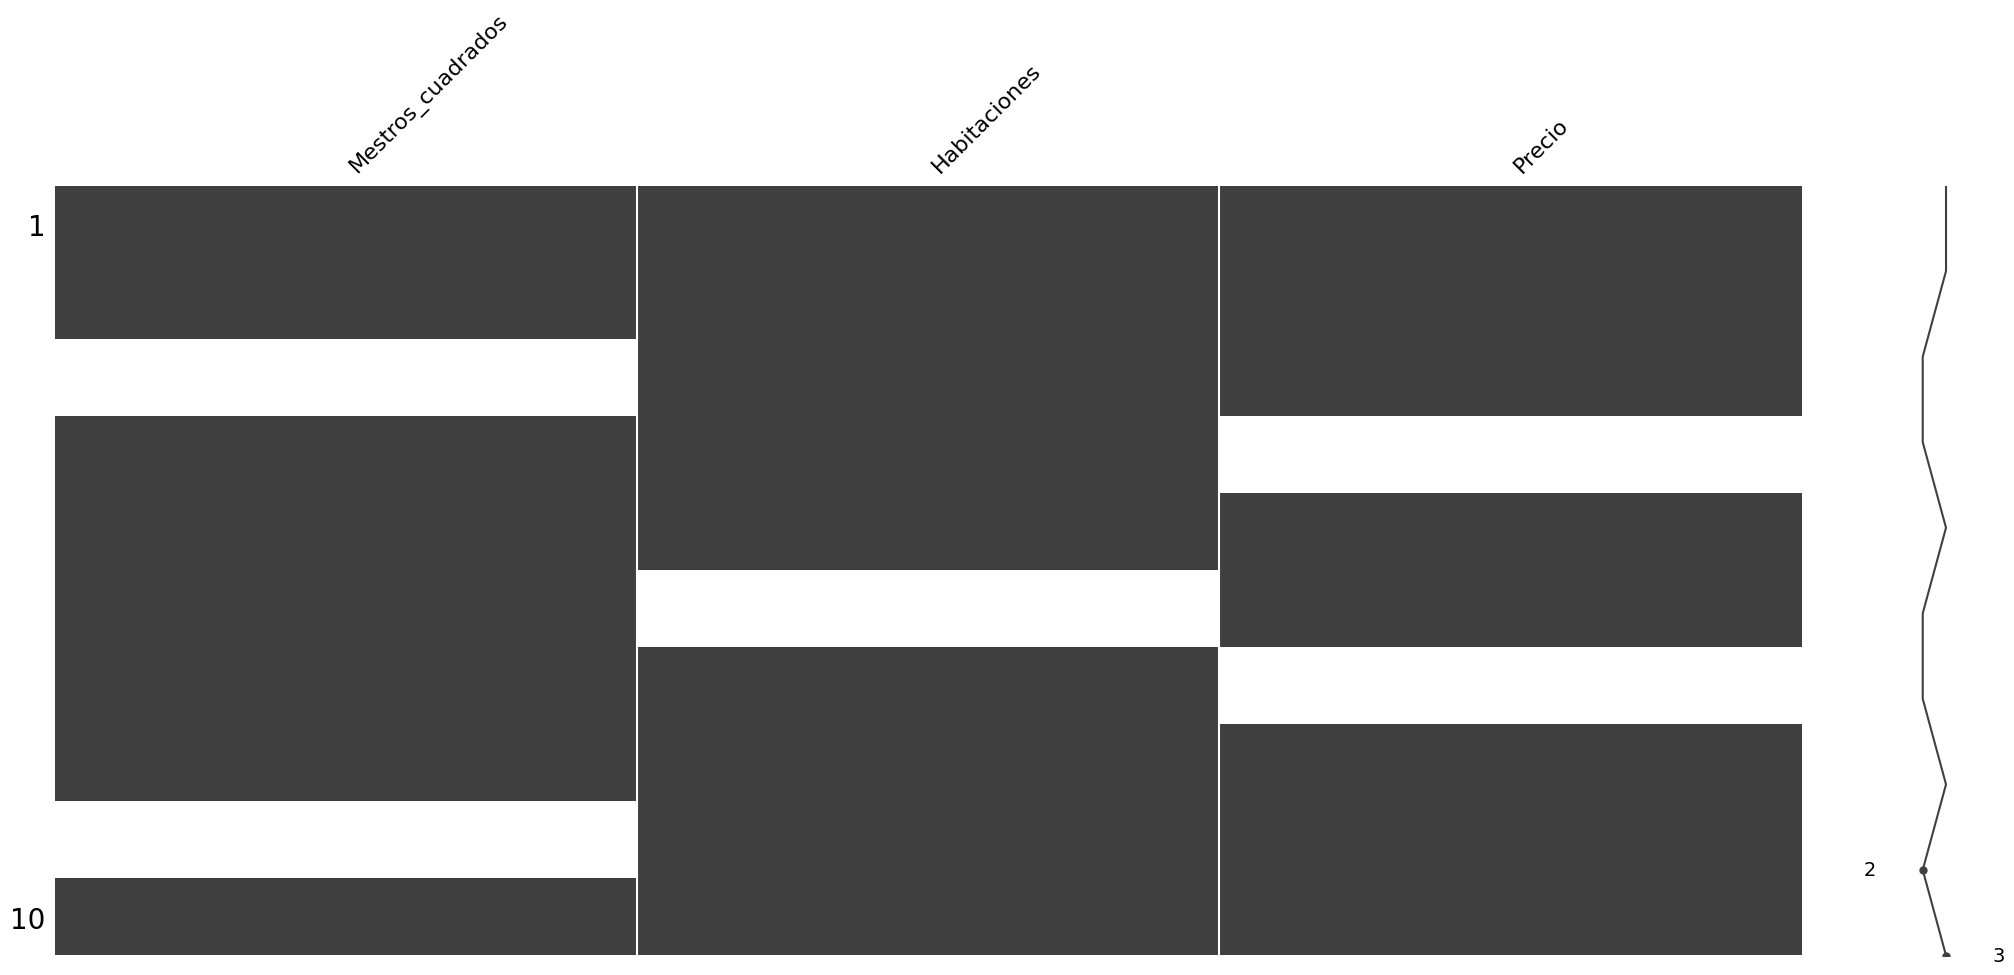

In [ ]:
import pandas as pd
import numpy as np
import missingno as mno
from sklearn.impute import KNNImputer

#Dataset de ejemplo con valores faltantes (NaN) en varias columnas.
df_inmobiliario=pd.DataFrame({
    
    'Metros_cuadrados':[85,120,np.nan,250,65,110,95,300,np.nan,150],
    'Habitaciones':[2,3,2,4,1,np.nan,2,5,2,3],
    'Precio':[150,210,140,np.nan,90,195,np.nan,520,160,260]
    
})

#Diagnostico programatico de valores faltantes.
#isnull() crea una mascara booleana, mean() calcula la proporcion de valores nulos,
#y multiplicamos por 100 para obtener el porcentaje por columna.
print("Porcentaje de valores nulos por columna")
porcentaje_nulos=df_inmobiliario.isnull().mean()*100
print(porcentaje_nulos)
print()

#Suma de valores nulos por columna para conocer el conteo absoluto de valores faltantes.
print("Cantidad de nulos por columna")
cantidad_nulos=df_inmobiliario.isnull().sum()
print(cantidad_nulos)
print()

#Diagnostico visual de los nulos usando missingno.
#Esto muestra una matriz de calor donde se visualiza que celdas están vacias.
print("Matriz de nulos")
mno.matrix(df_inmobiliario)
print()

#Estrategias de mitigacion de valores faltantes.
#1. Eliminacion listwise: eliminar filas que contienen cualquier valor nulo.
#Esta opcion puede ser util cuando la cantidad de nulos es baja y no se desea imputar.
df_eliminacion=df_inmobiliario.dropna()
print(f"Tamaño original: {df_inmobiliario.shape[0]} filas")
print(f"Tamaño despues de eliminacion: {df_eliminacion.shape[0]} filas")
print()

#2. Imputacion simple: reemplazar valores faltantes con una estadistica del conjunto.
#Aqui usamos la mediana de la columna 'Precio' para sustituir sus valores nulos.
df_mediana=df_inmobiliario.copy()
mediana_precio=df_mediana['Precio'].median()
df_mediana['Precio']=df_mediana['Precio'].fillna(mediana_precio)
print(f"Valor calculado de la mediana de Precio: {mediana_precio}")
print(df_mediana)
print()

#3. Imputacion avanzada: KNNImputer estima valores faltantes usando filas similares.
#El imputador busca los k vecinos mas cercanos y reemplaza los NaN con valores estimados.
df_knn=df_inmobiliario.copy()
imputador_knn=KNNImputer(n_neighbors=2)
datos_imputados_knn=imputador_knn.fit_transform(df_knn)

df_knn_final=pd.DataFrame(datos_imputados_knn,columns=df_inmobiliario.columns)
print("DataFrame con imputacion KNN")
print(df_knn_final)
